# *i love santa barbara zoo*

In [34]:
!pip install requests tqdm

In [1]:
#Configs
IMG_ROWS, IMG_COLS = 224, 224  # Matches transform
IMG_CHANNELS = 3
NB_CLASSES = 16  # Adjust based on your species count
BATCH_SIZE = 32

In [2]:
animals = [
    "Panthera leo",                 # African Lion
    "Panthera pardus orientalis",   # Amur Leopard
    "Aonyx cinereus",               # Asian Small-Clawed Otter
    "Notamacropus rufogriseus",     # Bennett's Wallaby
    "Gymnogyps californianus",      # California Condor
    "Hydrochoerus hydrochaeris",    # Capybara
    "Phoenicopterus chilensis",     # Chilean Flamingo
    "Alligator sinensis",           # Chinese Alligator
    "Urocyon littoralis",           # Island Fox
    "Giraffa camelopardalis tippelskirchi", # Masai Giraffe
    "Panthera uncia",               # Snow Leopard
    "Cacatua galerita",             # Sulphur-Crested Cockatoo
    "Podargus strigoides",          # Tawny Frogmouth
    "Macropus fuliginosus",         # Western Grey Kangaroo
    "Gorilla gorilla gorilla",      # Western Lowland Gorilla
    "Hylobates lar"                 # White-Handed Gibbon
]

In [3]:
import requests, os
from tqdm import tqdm

def download_species_images(species_name, max_images=50):
    folder = f"./data/{species_name.replace(' ', '_')}"
    os.makedirs(folder, exist_ok=True)

    url = "https://api.inaturalist.org/v1/observations"
    params = {
        "taxon_name": species_name,
        "per_page": max_images
    }

    response = requests.get(url, params=params).json()

    for i, obs in enumerate(tqdm(response.get("results", []))):
        try:
            img_url = obs["photos"][0]["url"].replace("square", "large")
            img_data = requests.get(img_url).content

            with open(f"{folder}/{i}.jpg", "wb") as f:
                f.write(img_data)
        except:
            pass

In [38]:
for animal in animals:
    download_species_images(animal, max_images=1000)

100%|██████████| 200/200 [01:13<00:00,  2.72it/s]


In [4]:
from PIL import Image
import os

def clean_dataset(root):
    removed = 0

    for root_dir, _, files in os.walk(root):
        for file in files:
            path = os.path.join(root_dir, file)

            try:
                with Image.open(path) as img:
                    img.verify()  # check if valid
            except:
                os.remove(path)
                removed += 1

    print(f"Removed {removed} corrupted images")

clean_dataset("./data")

Removed 0 corrupted images


In [5]:
import torch
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [6]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

dataset = ImageFolder(
    root="./data",
    transform=transform
)

#loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [42]:
# augementation here

In [7]:
from collections import Counter

# dataset.targets is a list of integers [0, 0, 1, 2, ...]
counts = Counter(dataset.targets)

# Map the indices back to the class names
for idx, count in counts.items():
    class_name = dataset.classes[idx]
    print(f"Class: {class_name} | Total Images: {count}")

Class: Alligator_sinensis | Total Images: 195
Class: Aonyx_cinereus | Total Images: 191
Class: Cacatua_galerita | Total Images: 191
Class: Giraffa_camelopardalis_tippelskirchi | Total Images: 200
Class: Gorilla_gorilla_gorilla | Total Images: 198
Class: Gymnogyps_californianus | Total Images: 199
Class: Hydrochoerus_hydrochaeris | Total Images: 198
Class: Hylobates_lar | Total Images: 180
Class: Macropus_fuliginosus | Total Images: 200
Class: Notamacropus_rufogriseus | Total Images: 200
Class: Panthera_leo | Total Images: 167
Class: Panthera_pardus_orientalis | Total Images: 194
Class: Panthera_uncia | Total Images: 180
Class: Phoenicopterus_chilensis | Total Images: 198
Class: Podargus_strigoides | Total Images: 193
Class: Urocyon_littoralis | Total Images: 198


In [8]:
print(dataset)
print(dataset.samples[:5])
print(dataset.classes)
print(len(dataset.classes))

Dataset ImageFolder
    Number of datapoints: 3082
    Root location: ./data
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )
[('./data/Alligator_sinensis/0.jpg', 0), ('./data/Alligator_sinensis/1.jpg', 0), ('./data/Alligator_sinensis/10.jpg', 0), ('./data/Alligator_sinensis/100.jpg', 0), ('./data/Alligator_sinensis/101.jpg', 0)]
['Alligator_sinensis', 'Aonyx_cinereus', 'Cacatua_galerita', 'Giraffa_camelopardalis_tippelskirchi', 'Gorilla_gorilla_gorilla', 'Gymnogyps_californianus', 'Hydrochoerus_hydrochaeris', 'Hylobates_lar', 'Macropus_fuliginosus', 'Notamacropus_rufogriseus', 'Panthera_leo', 'Panthera_pardus_orientalis', 'Panthera_uncia', 'Phoenicopterus_chilensis', 'Podargus_strigoides', 'Urocyon_littoralis']
16


In [9]:
from torch.utils.data import random_split, DataLoader

# total size
dataset_size = len(dataset)

# split sizes
train_size = int(0.8 * dataset_size)
test_size = dataset_size - train_size

# split
train_data, test_data = random_split(dataset, [train_size, test_size])

In [10]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [11]:
# Assuming 'train_loader' is your DataLoader
images, labels = next(iter(train_loader))

print(f"Number of classes defined: {NB_CLASSES}")
print(f"Max label value in batch: {labels.max().item()}")
print(f"Min label value in batch: {labels.min().item()}")

if labels.max().item() >= NB_CLASSES:
    print("ERROR: Your labels exceed the model output size!")
elif labels.min().item() < 0:
    print("ERROR: Negative labels found!")
else:
    print("Labels look good. Proceeding to GPU.")

Number of classes defined: 16
Max label value in batch: 14
Min label value in batch: 0
Labels look good. Proceeding to GPU.


In [12]:
from torchvision import models
import torch.nn as nn
import torch.nn.functional as F

class LAESMobileNet(nn.Module):
    def __init__(self):
        super(LAESMobileNet, self).__init__()
        # Conv2D(32, (3, 3))
        self.conv1 = nn.Conv2d(IMG_CHANNELS, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)

        # Flattening logic: 224 -> 112 after MaxPool
        self.flatten_size = 32 * (IMG_ROWS // 2) * (IMG_COLS // 2)

        self.fc1 = nn.Linear(self.flatten_size, 512)
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, NB_CLASSES)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.dropout1(x)
        x = x.view(-1, self.flatten_size) # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

model = LAESMobileNet()

In [13]:
# Assuming your loader gives you (images, labels)
images, labels = next(iter(train_loader))

# 1. Check unique labels again if you want to be sure
print(f"Unique labels in batch: {torch.unique(labels)}")

# 2. Check the model output shape (use 'images' here)
model.eval() # Set to eval mode so dropout doesn't run
with torch.no_grad():
    output = model(images)
    print(f"Model output shape: {output.shape}")

Unique labels in batch: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 13, 14, 15])
Model output shape: torch.Size([32, 16])


In [14]:
# Quick safety check on the CPU
images, labels = next(iter(train_loader))
max_label = labels.max().item()
num_outputs = model.fc2.out_features

print(f"Max label in data: {max_label}")
print(f"Model output size: {num_outputs}")

if max_label >= num_outputs:
    raise ValueError(f"CRASH IMMINENT: Label {max_label} is out of bounds for model with {num_outputs} outputs!")

Max label in data: 15
Model output size: 16


In [17]:
import torch

# Define the device again
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Re-initialize the model and move it to the device
model = LAESMobileNet().to(device)

# Re-define your loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Using device: cuda


In [18]:
for epoch in range(50):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Avg Loss: {total_loss / len(train_loader):.4f}")

Epoch 1, Avg Loss: 6.2317
Epoch 2, Avg Loss: 2.7291
Epoch 3, Avg Loss: 2.7140
Epoch 4, Avg Loss: 2.6983
Epoch 5, Avg Loss: 2.7239
Epoch 6, Avg Loss: 2.7035
Epoch 7, Avg Loss: 2.6861
Epoch 8, Avg Loss: 2.6398
Epoch 9, Avg Loss: 2.6528
Epoch 10, Avg Loss: 2.6271
Epoch 11, Avg Loss: 2.6247
Epoch 12, Avg Loss: 2.5348
Epoch 13, Avg Loss: 2.4426
Epoch 14, Avg Loss: 2.3820
Epoch 15, Avg Loss: 2.2601
Epoch 16, Avg Loss: 2.2116
Epoch 17, Avg Loss: 2.1085
Epoch 18, Avg Loss: 2.0144
Epoch 19, Avg Loss: 1.8465
Epoch 20, Avg Loss: 1.8004
Epoch 21, Avg Loss: 1.6070
Epoch 22, Avg Loss: 1.5288
Epoch 23, Avg Loss: 1.4024
Epoch 24, Avg Loss: 1.3266
Epoch 25, Avg Loss: 1.2204
Epoch 26, Avg Loss: 1.0708
Epoch 27, Avg Loss: 1.0231
Epoch 28, Avg Loss: 0.9340
Epoch 29, Avg Loss: 0.8960
Epoch 30, Avg Loss: 0.8173
Epoch 31, Avg Loss: 0.8394
Epoch 32, Avg Loss: 0.7548
Epoch 33, Avg Loss: 0.6964
Epoch 34, Avg Loss: 0.6517
Epoch 35, Avg Loss: 0.6058
Epoch 36, Avg Loss: 0.6097
Epoch 37, Avg Loss: 0.5938
Epoch 38, 

In [19]:
# check to cpu
model.to('cpu')
model.eval()

# Create a dummy input matching your transform (1, 3, 224, 224)
dummy_input = torch.randn(1, 3, 224, 224)

# Run a forward pass
try:
    with torch.no_grad():
        output = model(dummy_input)
    print("CPU Check Passed: Model is ready for export.")
except Exception as e:
    print(f"CPU Check Failed: {e}")

# Export if passed
torch.save(model.state_dict(), "animal_model.pth")

CPU Check Passed: Model is ready for export.


In [20]:
import torch

torch.save({
    "model_state_dict": model.state_dict(),
    "classes": dataset.classes
}, "animal_model_v2.pth")

In [21]:
import matplotlib.pyplot as plt
import torch

def show_predictions(model, loader, classes, device):
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    images = images.cpu()

    fig = plt.figure(figsize=(10, 10))

    for i in range(9):  # show 9 images
        ax = fig.add_subplot(3, 3, i+1)
        img = images[i].permute(1, 2, 0)

        ax.imshow(img)
        ax.set_title(f"Pred: {classes[preds[i]]}\nTrue: {classes[labels[i]]}")
        ax.axis("off")

    plt.show()

In [22]:
print(dataset.classes)

['Alligator_sinensis', 'Aonyx_cinereus', 'Cacatua_galerita', 'Giraffa_camelopardalis_tippelskirchi', 'Gorilla_gorilla_gorilla', 'Gymnogyps_californianus', 'Hydrochoerus_hydrochaeris', 'Hylobates_lar', 'Macropus_fuliginosus', 'Notamacropus_rufogriseus', 'Panthera_leo', 'Panthera_pardus_orientalis', 'Panthera_uncia', 'Phoenicopterus_chilensis', 'Podargus_strigoides', 'Urocyon_littoralis']


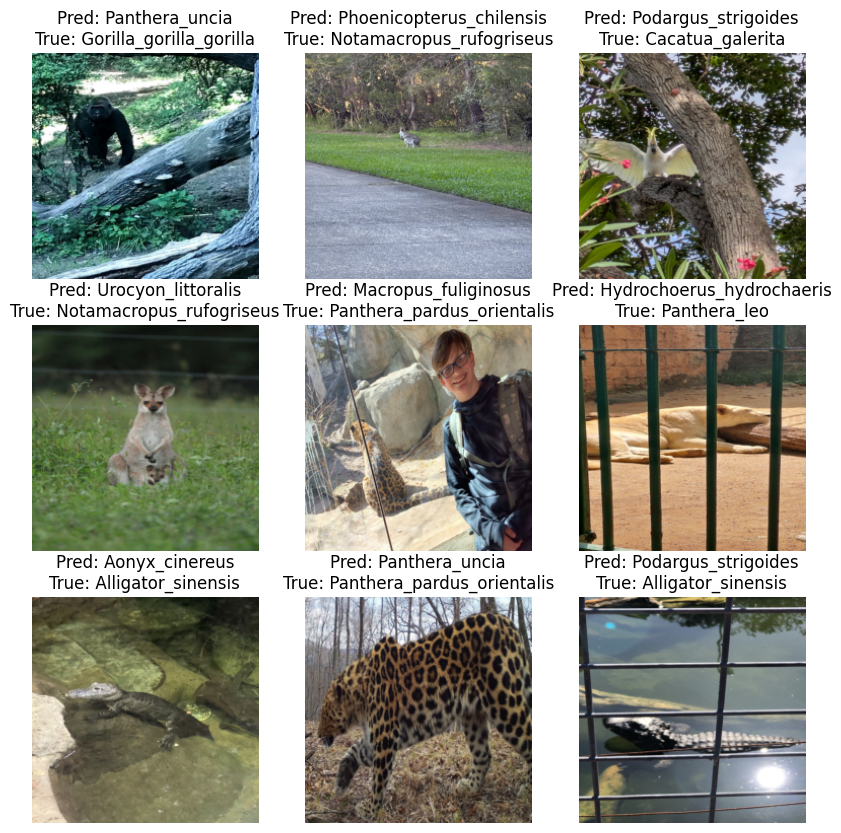

In [25]:
model = model.to(device)

# 2. Now run your prediction function
show_predictions(model, test_loader, dataset.classes, device)

In [26]:
print(next(model.parameters()).is_cuda)

True


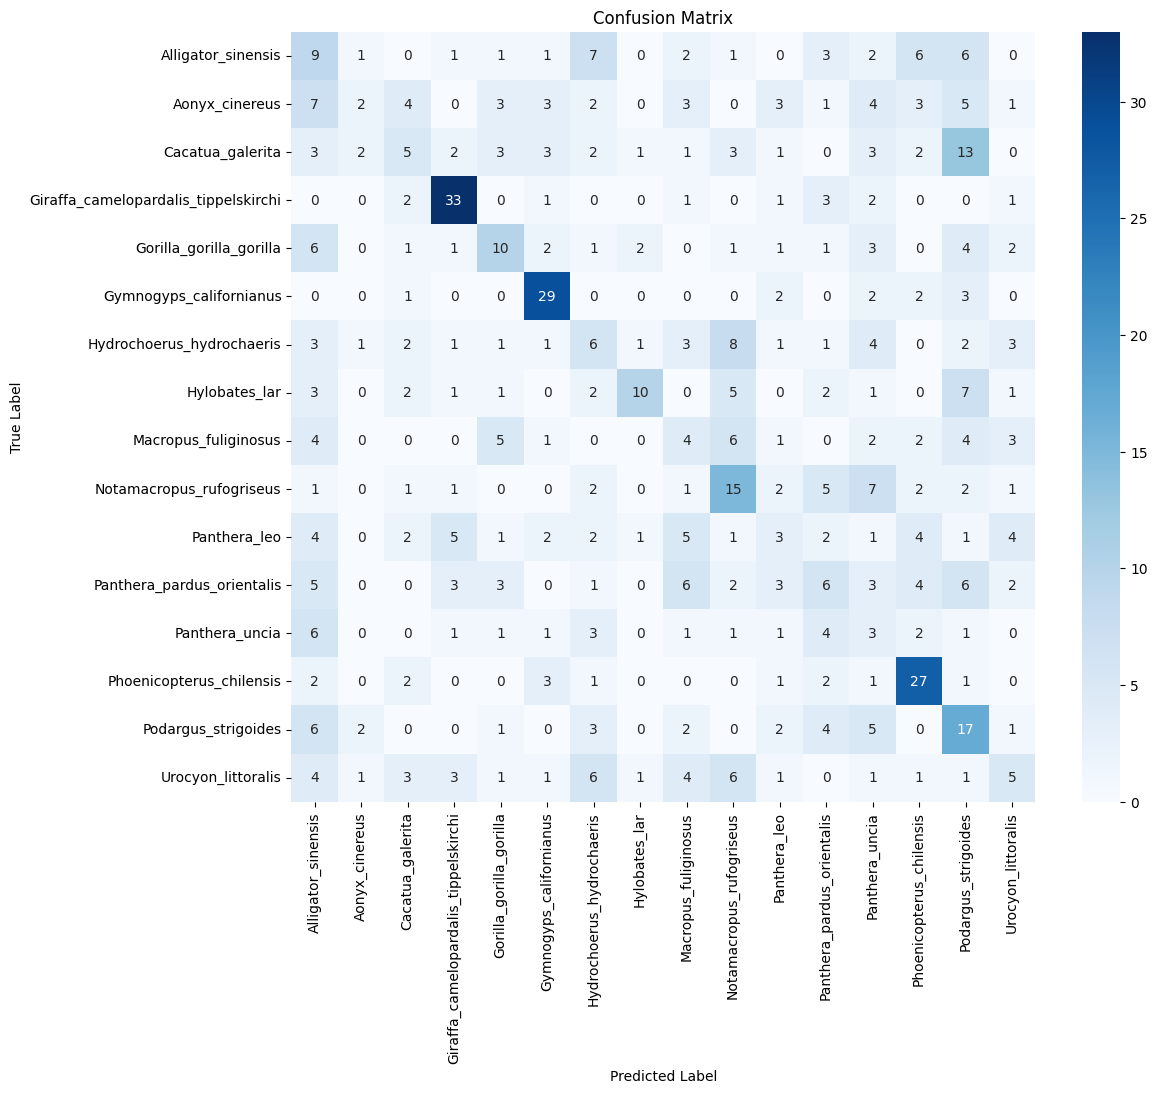

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(model, loader, classes, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Generate the matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plotting
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

# Run it
plot_confusion_matrix(model, test_loader, dataset.classes, device)
